# Condensator Ontwerpopdracht

Bij het vak elektromagnetisme zullen jullie in de eerste paar weken diep ingaan op de elektrostatica. Parallel hieraan zullen we bij het vak DEF-D, naast de fysieke ontwerpopdrachten en colleges, deze simulatie-ontwerpopdracht behandelen. Deze simulatie-opdracht is weer nauw verwoven met de tweede fysieke ontwerpopdracht die in week 3.3 gegeven wordt. Je moet het grootste deel van deze simulatie opdracht afronden voordat je aan de fysieke ontwerpopdracht van week 3.3 begint. Het laatste stuk van deze simulatie opdracht maak je na afloop van de fysieke opdracht. De deadline voor het inleveren van deze simulatie-opdracht is in week 3.4

Je werkt bij deze opdracht in teams die wij indelen. Zoek op Brightspace op met wie je samenwerkt en leg via email contact. Maak goede afspraken over hoe je samen gaat werken.

In deze simulatie opdracht beginnen we met een aantal simulaties van verschillende situaties, die jullie daarna zullen interpreteren. Daarna zal wat essentiële voorbereiding op de tweede fysieke ontwerpopdracht besproken worden. En als laatste zal dieper ingegaan worden op hoe jullie metingen van de tweede ontwerpopdracht afwijken van de theorie.

De opdracht bestaat uit de volgende sub-opdrachten die je moet doen voordat je begint aan de fysieke ontwerpopdracht van week 3.3:
1) Een puntlading in de oorsprong.
2) Een uniform geladen schijf bestaande uit puntladingen.
3) Een geladen schijf op een constant potentiaal.
4) Twee geleidende platen op potentiaal $V_1$ and $-V_1$.
5) Voorbereidende opdracht voor de DEF ontwerpopdracht.

Na de fysieke ontwerpopdracht van week 3.3 kan je ten slotte het laatste deel doen:

6) Reflectie opdracht voor na de fysieke ontwerpopdracht.

De opdracht wordt volledig online gedaan, er zullen hiervoor dus ook geen specifieke werkcolleges voor zijn ingeroosterd. Als jullie vragen hebben kunnen jullie die mailen naar het DEF e-mailadres: DEF-TNW@tudelft.nl. Deze opdracht wordt in week 3.4 beoordeeld en herkansingen zijn in week 3.5, zie de studiehandleiding voor details.
   
Technische Instructies:
- Git clone (als nog niet gedaan) het DEF repo en maak een branch voor werken aan deze opdracht. Nodig je groepsgenoot uit als collaborator. Hiervoor staat een manual op brightspace.
- Dit notebook maakt gebruik van een aantal functies die in het bestand ```functions_electrostatics.py``` staan. Dit bestand moet in dezelfde map (folder) staan als dit notebook. Als je git clone doet, gaat dat automatisch goed, maar verplaats dit notebook dus niet naar een andere map, mail het niet naar een mede-student, etc. Als je niet weet wat een map (folder) en een bestand is, bekijk dan [deze tutorial](https://teachbooks.io/files-and-folders/EN/intro.html).

Onderwijs Instructies:
- Beantwoord de vragen die in dit notebook voor komen direct in dit notebook.
- Als je iets moet printen op het scherm als antwoord op een vraag, doe dit op een gestructureerde manier met als dat relevant is de eenheid erbij, zoals je geleerd is bij het Inleidend Practicum.
- Vermijd 'hardcoden' waar mogelijk.
- Bij elke code cel staat aangegeven of jij hem moet aanpassen of alleen runnen. Lees bij cellen die je moet runnen, maar niet hoeft aan te passen, goed de code door om daarvan te leren en te gebruiken in de cellen die je wel moet aanpassen.

Elektrostatica Opmerkingen:
- In deze opdracht zullen jullie verschillende problemen bestuderen die as-symmetrie hebben. De opdrachten zullen daardoor, cilindrische coördinaten ($r$,$\phi$,$z$) gebruiken, waarbij $r$ de afstand tot de $z$ as is, $z$ de hoogte en $\phi$ de hoek met de $x$-as. Alle gebruikte problemen zullen ook in de $\phi$ richting symmetrisch zijn en die coördinaat zal dus niet uitmaken.
- Voor elke sub-opdracht zal eerst het potentiaal bepaald worden en daarna zal het elektrische veld bepaald worden met de "finite difference" methode. Dit is een methode om de afgeleide te nemen van een dataset. Deze methode is geen onderdeel van de leerdoelen van het vak en komt later in je studie aan bod. We gebruiken "finite difference" hier als gereedschap en als voorbeeld van wat je later nog tegen gaat komen.



Vul de informatie in deze cel in:

| Groep: 59     |  |
| :-------------|:-------------|
| Farzat Darboli | 6535925 |
| Marjoksi Elyas | Student Studienummer 2 |

In [3]:
# Run deze cel, pas deze niet aan
import numpy as np
import matplotlib.pyplot as plt
from functions_electrostatics import *
#from IPython import display
from IPython.display import Image, display


epsilon0 = 8.854e-12  # permittiviteit van vacuum (F/m)

"""============================================================================================
We first define the size of the domain of calculation and spatial discretization of the domain
"""

# Grid van het rekendomein; het veld wordt berekend in het (r,z)-vlak (asymmetrie):
width_domain = 5  # (m)
height_domain = width_domain  # maximum afstand van de schijf tot de grond, boven en beneden (m)
grid_step = 0.1  # grid stap grootte (m)

### 1) Een puntlading in de oorsprong

In deze opdracht gaan we in op een numerieke benadering van het potentiaal en elektrische veld rond een puntlading in de oorsprong. 

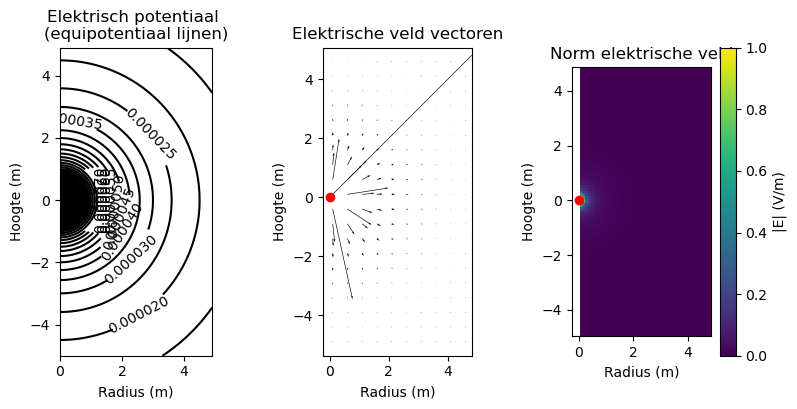

In [4]:
# Run deze cel, pas de cel niet aan
charge_one_point = 1e-14  # lading van 1 punt (C)

r, z, B = initialize_plane_grid_for_pt_charge_at_origin(height_domain, width_domain, grid_step)
V = calculate_V_point_charge_at_origin(charge_one_point, r, z)

Er, Ez, normE = compute_E_pt_charge(V, B, grid_step)  # gebruik de centered finite-difference method
# met Er de r-component, Ez de z-component en normE de norm van het elektrische veld

r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

plot_results_pt_charge_at_origin(Ez, Er, normE, V, r, z, grid_step)


##### Vraag 1a Het potentiaal rond een puntlading

1. Bepaal welke index correspondeert met $z = 0$ m.
2. Plot de log van het potentiaal tegen de log van de straal.
3. Fit de log van het potentiaal met de log van de straal.
4. Print het exponent op een nette manier.

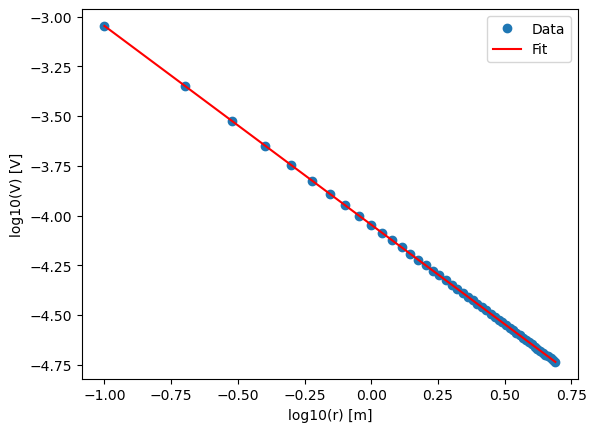

De berekende exponent voor V is: -1.0000000000000004


In [5]:
index_z0 = np.argmin(np.abs(z))

straal = r[1:]
potentiaal = V[index_z0, 1:]

log_r = np.log10(straal)
log_V = np.log10(potentiaal)

plt.figure()
plt.plot(log_r, log_V, 'o', label='Data')

fit_resultaat = np.polyfit(log_r, log_V, 1)
exponent_V = fit_resultaat[0]
plt.plot(log_r, np.polyval(fit_resultaat, log_r), 'r-', label='Fit')

plt.xlabel('log10(r) [m]')
plt.ylabel('log10(V) [V]')
plt.legend()
plt.show()

print("De berekende exponent voor V is:", exponent_V)

##### Vraag 1b Het elektrische veld rond een puntlading
1. Voer van vraag 1a 2 tot 4 uit voor het elektrische veld.

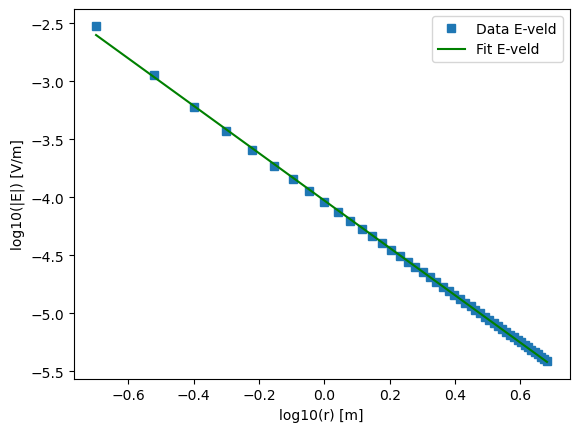

De berekende exponent voor |E| is: -2.0403594570178174


In [6]:
index_z0_E = np.argmin(np.abs(z_for_E))

straal_E = r_for_E[1:]
E_veld = normE[index_z0_E, 1:]

log_r_E = np.log10(straal_E)
log_E = np.log10(E_veld)

plt.figure()
plt.plot(log_r_E, log_E, 's', label='Data E-veld')

fit_resultaat_E = np.polyfit(log_r_E, log_E, 1)
exponent_E = fit_resultaat_E[0]
plt.plot(log_r_E, np.polyval(fit_resultaat_E, log_r_E), 'g-', label='Fit E-veld')

plt.xlabel('log10(r) [m]')
plt.ylabel('log10(|E|) [V/m]')
plt.legend()
plt.show()

print("De berekende exponent voor |E| is:", exponent_E)

### 2) Een uniform geladen schijf bestaande uit puntladingen

In de code hieronder wordt een geladen schijf gemaakt via het superpositie principe. Dit wordt gedaan door een rooster van punten in de ruimte te creëren, alle punten die voldoen aan $z = 0$ m en $r < R$ krijgen een lading charge_one_point en vanuit hier wordt het potentiaal bepaald. Hier is de $z$-as de as van de schijf en de r as de afstand tot de $z$-as.



In [7]:
# In vraag 2.1 wordt naar deze cel verwezen.
disk_radius = 3  # (m)
grid_step = 0.1  # (m)
z_coord_DISK = 0  # (m) positie van de schijf op de z-as
inter_charge_distance = grid_step  # (m) afstand tussen punt ladingen

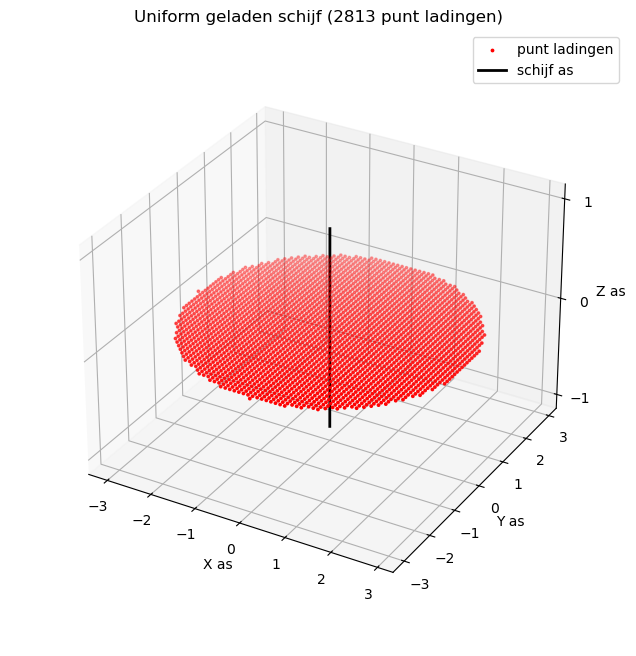

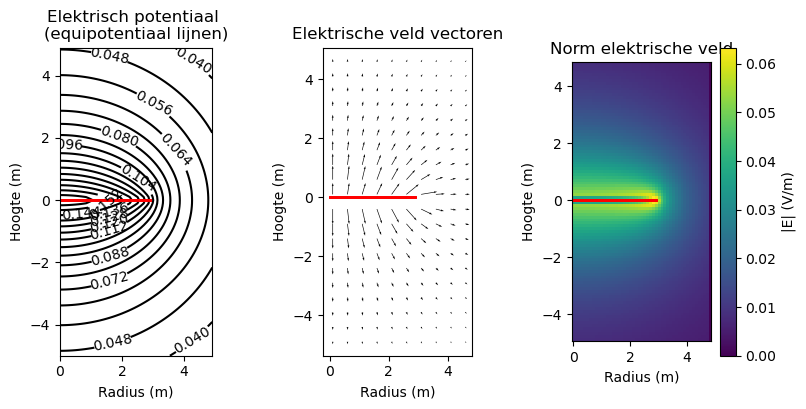

In [8]:
# Kies uit deze cel een van de variabelen en verander die in de cel hierboven pas deze cel zelf niet aan.
r, z, B = initialize_plane_grid_for_uniformly_charged_disk(height_domain, width_domain, grid_step)

idx_z_zero = np.where(abs(z) < 1e-10)[0]
z_coord_DISK = 0  # (m) positie van de schijf op de z-as
inter_charge_distance = grid_step  # (m) afstand tussen punt ladingen

V, number_point_charges_on_disk = calculate_V_disk_at_origin_uniform_surface_charge_density(z_coord_DISK, charge_one_point, disk_radius, inter_charge_distance, r, z)
Er, Ez, normE = compute_E_disk(V, B, grid_step)  # gebruik de centered finite-difference method

r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

plot_results_disk(Ez, Er, normE, V, r, z, grid_step, disk_radius, z_coord_DISK, z_coord_DISK)

#### Vraag 2a

In deze vraag gaan jullie achterhalen wat de variabelen die aan het begin van opgave 2 worden geïnitialiseerd betekenen voor de nauwkeurigheid en snelheid van de code.
Pas voor deze vraag de code die net onder het kopje vraag 2 staat aan. Run dan die cel en de cel daaronder opnieuw om het resultaat van je aanpassing te zien.
1. Wat betekent de disk radius variabele die in de bovenste cel geïnitialiseerd wordt, wat gebeurt er als disk radius naar 0 gaat?
2. Wat betekent gridstep en wat voor impact heeft deze variabele op de simulatie?
3. Pak uit de tweede code cel in opdracht 2 een andere variabelen en onderzoek wat deze variabele doet en wat voor impact die heeft op de simulatie.

##### Antwoorden 2a


1. **Betekenis van `disk_radius`:**
   De variabele `disk_radius` bepaalt de fysieke straal ($R$) van de gesimuleerde schijf in meters. Wanneer de `disk_radius` naar 0 gaat, krimpt de schijf tot een enkel punt. In dat geval verandert de situatie terug naar die van een puntlading, zoals we die in opdracht 1 hebben bestudeerd.

2. **Betekenis van `grid_step`:**
   De `grid_step` bepaalt de resolutie van het rekendomein, oftewel de afstand tussen de punten waarop de computer het potentiaal en het veld berekent. 
   * **Impact:** Een kleinere `grid_step` zorgt voor een nauwkeuriger resultaat omdat de data fijner wordt berekend. Echter, dit verhoogt de rekentijd aanzienlijk omdat er veel meer punten berekend moeten worden.

3. **Onderzoek naar `inter_charge_distance`:**
   Ik heb gekozen voor de variabele `inter_charge_distance`, welke de afstand tussen de individuele puntladingen op de schijf bepaalt. 
   * **Impact:** Deze variabele beïnvloedt hoe "glad" de ladingsverdeling op de schijf is. Als deze afstand veel groter wordt dan de `grid_step`, wordt de schijf niet meer als een uniform vlak gezien maar als een verzameling losse punten, wat de nauwkeurigheid van de simulatie van de oppervlakte-ladingsdichtheid verslechtert.

#### Vraag 2b Oppervlakte lading

Pas de cel die je in vraag 2a hebt aangepast weer aan naar de originele waardes. Run hierna alle code cellen na vraag 2 weer opnieuw.
Het aantal punten dat gebruikt wordt om de schijf te creëren is number_point_charges_on_disk en de lading van een punt is charge_one_point in Coulomb.
1. Bereken en print de ladingsdichtheid $\sigma$ met een correcte eenheid.

In [9]:
# Bereken de totale lading op de schijf
totale_lading = number_point_charges_on_disk * charge_one_point

# Bereken het oppervlak van de schijf (A = pi * r^2)
oppervlakte_schijf = np.pi * disk_radius**2

# Bereken de ladingsdichtheid sigma (lading per m^2)
sigma = totale_lading / oppervlakte_schijf

# Print de resultaten op een nette manier
print(f"Aantal puntladingen op de schijf: {number_point_charges_on_disk}")
print(f"Totale lading op de schijf: {totale_lading:.4e} C")
print(f"De berekende ladingsdichtheid (sigma) is: {sigma:.4e} C/m^2")

Aantal puntladingen op de schijf: 2813
Totale lading op de schijf: 2.8130e-11 C
De berekende ladingsdichtheid (sigma) is: 9.9490e-13 C/m^2


##### Vraag 2c

1. Plot het elektrische potentiaal langs de $r$ as ($z = 0$ m).
2. Plot het potentiaal op de rand van de schijf in hetzelfde figuur $V = \sigma R/(\pi \epsilon_0)$
(bekijk probleem 2.51 in het Griffiths' boek)
3. Plot het potentiaal in het centrum van de schijf in hetzelfde figuur $V = \sigma R/(2 \epsilon_0)$

Text(0, 0.5, 'Potentiaal V [V]')

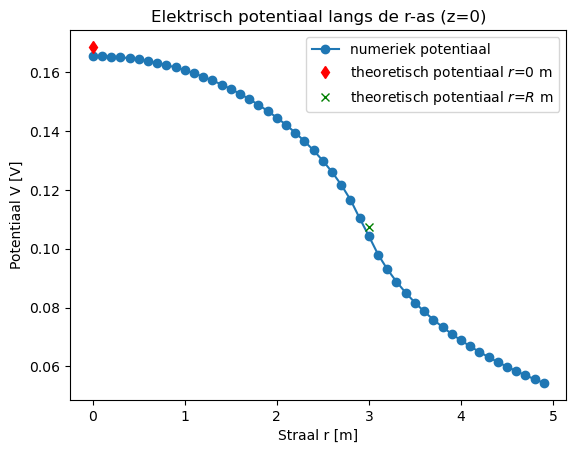

In [10]:
# Vul deze code aan zodat deze vraag 2.3 beantwoord.
idx_z_zero = np.argmin(np.abs(z))

V_0 = (sigma * disk_radius) / (2 * epsilon0)

V_R =  (sigma * disk_radius) / (np.pi * epsilon0)
r_R =  disk_radius

plt.title("Elektrisch potentiaal langs de r-as (z=0)")
plt.plot(r, V[idx_z_zero, :], "o-", label="numeriek potentiaal")
plt.plot(0, V_0, "rd", label="theoretisch potentiaal $r$=0 m")
plt.plot(r_R, V_R, "gx", label="theoretisch potentiaal $r$=$R$ m")
plt.legend()
plt.xlabel("Straal r [m]")
plt.ylabel("Potentiaal V [V]")



#### Vraag 2d

Het theoretische potentiaal op de as van een hele grote schijf ($R>>z$) is:
$V(z, r=0) = \frac{\sigma}{2\epsilon_0} \big( R - |z|\big)$
zie probleem 2.26 in het Griffiths boek.
1. Plot het numeriek berekend elektrische potentiaal op de $z$-as ($r=0$).
2. Plot het theoretische component van het potentiaal op de as van een schijf met ladingsdichtheid $\sigma$.
3. Sla deze plot op.


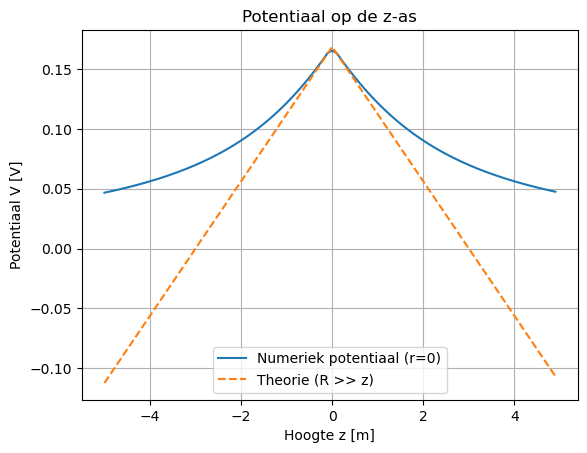

In [11]:
idx_r_zero = np.argmin(np.abs(r))

V_numeriek_z = V[:, idx_r_zero]

V_theorie_z = (sigma / (2 * epsilon0)) * (disk_radius - np.abs(z))

plt.figure()
plt.plot(z, V_numeriek_z, label='Numeriek potentiaal (r=0)')
plt.plot(z, V_theorie_z, '--', label='Theorie (R >> z)')

plt.title("Potentiaal op de z-as")
plt.xlabel("Hoogte z [m]")
plt.ylabel("Potentiaal V [V]")
plt.legend()
plt.grid(True)

plt.savefig("vraag2d_potentiaal_z_as.png")
plt.show()


#### Vraag 2e

Het theoretische elektrische veld van een oneindig geladen oppervlakte is $|E| = \sigma/(2 \epsilon_0)$ (zie Example 2.5 in het Griffith boek).
1. Plot het z-component van het numeriek berekende elektrische veld op de as van de schijf ($r=0$).
2. Plot het theoretische elektrische veld voor een oneindig geladen oppervlak.
3. Sla deze plot ook op.

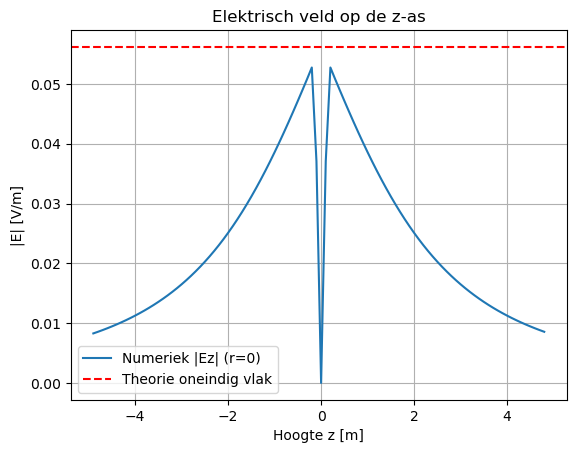

In [12]:
idx_r_zero_E = np.argmin(np.abs(r_for_E))

Ez_numeriek_z = Ez[:, idx_r_zero_E]

E_oneindig_vlak = sigma / (2 * epsilon0)

plt.figure()
plt.plot(z_for_E, np.abs(Ez_numeriek_z), label='Numeriek |Ez| (r=0)')
plt.axhline(y=E_oneindig_vlak, color='r', linestyle='--', label='Theorie oneindig vlak')

plt.title("Elektrisch veld op de z-as")
plt.xlabel("Hoogte z [m]")
plt.ylabel("|E| [V/m]")
plt.legend()
plt.grid(True)

plt.savefig("vraag2e_veld_z_as.png")
plt.show()

#### Vraag 2f
1. Waar benadert het elektrische veld van een uniform geladen schijf dat van een oneindig geladen plaat?
2. Beschrijf en verklaar de verschillen die je opvallen in de plot die je bij vraag 2e hebt gemaakt.

##### Antwoorden 2f


1. **Benadering van een oneindig geladen plaat:**
   Het elektrische veld van de uniform geladen schijf benadert dat van een oneindig geladen plaat wanneer de hoogte $z$ heel klein is ten opzichte van de straal $R$ van de schijf ($z \ll R$). In de plot is dit te zien bij de pieken vlakbij $z=0$, waar de numerieke waarde (blauwe lijn) de theoretische waarde van het oneindige vlak (rode stippellijn) bijna raakt.

2. **Beschrijving en verklaring van de verschillen:**
   In de plot vallen twee grote verschillen op tussen de numerieke schijf en de theoretische oneindige plaat:

   * **De dip naar nul bij $z=0$:** In het exacte midden van de schijf ($z=0, r=0$) is het elektrische veld in de z-richting nul. Dit komt door symmetrie: elke puntlading op de schijf heeft een tegenhanger aan de andere kant die een even groot maar tegengesteld gericht veld veroorzaakt, waardoor de z-componenten elkaar precies opheffen.
   * **Afname bij grotere $|z|$:** Terwijl het veld van een oneindig vlak overal constant blijft ($|E| = \sigma/2\epsilon_0$), neemt het veld van onze schijf snel af naarmate we verder weg bewegen. Dit komt doordat de schijf een beperkte afmeting heeft. Van een grote afstand begint de schijf steeds meer op een puntlading te lijken, waarbij de veldsterkte afneemt met $1/z^2$, in plaats van constant te blijven zoals bij een oneindig groot oppervlak.


#### Vraag 2g

1. Pas helemaal bovenaan in vraag 2 de straal van de schijf aan.
2. Voer dan vragen 2d en 2e opnieuw uit.
3. Voeg de opgeslagen figuren hieronder toe.
4. Beschrijf de verschillen tussen de twee verschillende stralen.

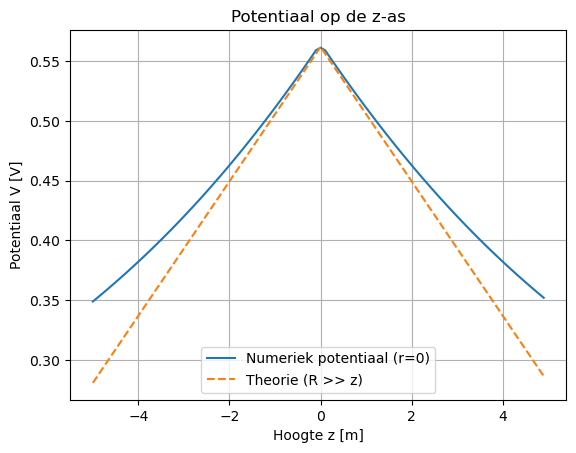

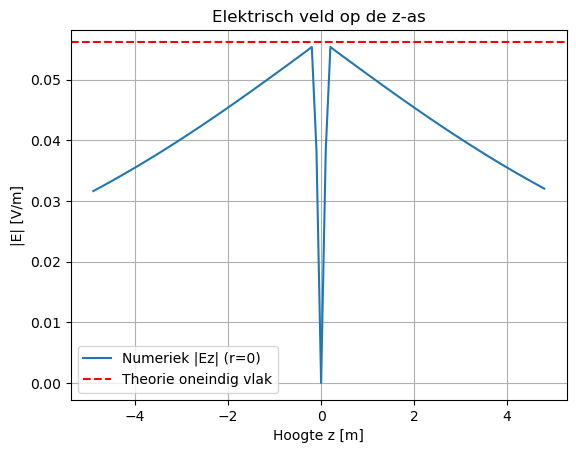

In [13]:
# Toevoeging van opgeslagen figuren voor straal = 10 
display(Image("vraag2d.png"))
display(Image("vraag2e.png"))

##### Antwoorden 2g

Door de straal van de schijf te vergroten van 3 meter naar 10 meter, zijn de volgende verschillen duidelijk zichtbaar in de simulatie:

* **Elektrisch Potentiaal ($V$):** Bij de grotere straal ($R=10$) is de maximale waarde van het potentiaal in het midden ($z=0$) aanzienlijk gestegen. Bovendien volgt de numerieke data de theoretische benadering voor een grote schijf ($V \approx \frac{\sigma}{2\epsilon_0}(R-|z|)$) over een veel groter bereik van de z-as . Waar de lijnen bij $R=3$ al snel uit elkaar liepen, blijven ze bij $R=10$ bijna de hele weg parallel lopen.

* **Elektrisch Veld ($|E|$):** In de grafiek van het elektrische veld is te zien dat het veld bij $R=10$ veel langer "plat" blijft en de theoretische waarde van een oneindig vlak ($\sigma/2\epsilon_0$) veel beter benadert. De invloed van de randen van de schijf (het 'edge effect') wordt pas op grotere hoogte merkbaar. Dit bevestigt dat hoe groter de schijf is, hoe beter deze zich in het centrum gedraagt als een ideaal, oneindig geladen oppervlak.

* **Conclusie:** Een grotere straal zorgt ervoor dat de aannames van een oneindig vlak langer geldig blijven, waardoor de simulatie over een groter gebied overeenkomt met de versimpelde analytische theorie.

#### Vraag 2h
Het elektrische veld een afstand $z$ boven het midden van een uniform geladen schijf met een straal $R$ en oppervlakte lading $\sigma$ wordt gegeven door:
$$ \mathbf{E} = \frac{\sigma}{2\epsilon_0} \bigg[ 1- \frac{z}{\sqrt{R^2 + z^2}}\bigg] \hat{\mathbf{z}}$$
Zie probleem 2.6 in het boek van Griffith.

1. Wat moet de hoogte $z$ zijn boven de schijf zodat het elektrische veld door de schijf 10% is in vergelijking met dat van een oneindig geladen plaat?

Voeg hieronder je analytische uitwerking toe.

##### Antwoord 2h


We zoeken de hoogte $z$ waarvoor geldt dat het elektrische veld van de schijf ($E_{schijf}$) gelijk is aan 10% van het veld van een oneindig geladen plaat ($E_{oneindig}$).

**1. De formules:**
Het elektrische veld van een oneindig geladen plaat is:
$$E_{oneindig} = \frac{\sigma}{2\epsilon_0}$$

Het elektrische veld op de as van een schijf met straal $R$ is:
$$E_{schijf} = \frac{\sigma}{2\epsilon_0} \left[ 1 - \frac{z}{\sqrt{R^2 + z^2}} \right]$$

**2. De vergelijking opstellen:**
We stellen $E_{schijf} = 0.10 \cdot E_{oneindig}$:
$$\frac{\sigma}{2\epsilon_0} \left[ 1 - \frac{z}{\sqrt{R^2 + z^2}} \right] = 0.10 \cdot \frac{\sigma}{2\epsilon_0}$$

**3. Oplossen voor $z$:**
De term $\frac{\sigma}{2\epsilon_0}$ valt aan beide kanten weg:
$$1 - \frac{z}{\sqrt{R^2 + z^2}} = 0.10$$
$$\frac{z}{\sqrt{R^2 + z^2}} = 0.90$$

Kwadrateer beide kanten om de wortel te verwijderen:
$$\frac{z^2}{R^2 + z^2} = 0.81$$
$$z^2 = 0.81(R^2 + z^2)$$
$$z^2 = 0.81R^2 + 0.81z^2$$
$$z^2 - 0.81z^2 = 0.81R^2$$
$$0.19z^2 = 0.81R^2$$
$$z^2 = \frac{0.81}{0.19} R^2$$
$$z = \sqrt{\frac{0.81}{0.19}} R \approx 2.065 R$$

**Conclusie:**
De hoogte $z$ moet ongeveer **$2.065$ keer de straal $R$** van de schijf zijn om de veldsterkte tot 10% te laten afnemen ten opzichte van een oneindig vlak. Voor jouw aangepaste straal van $R=10\text{ m}$ is dit dus op een hoogte van ongeveer **$20.65\text{ m}$**.

### 3) Een geladen schijf op een constant potentiaal

We zullen nu het verschil bestuderen tussen een uniform geladen schijf en een geleidende schijf die op een bepaald potentiaal gehouden wordt.
De code hieronder lost numeriek de laplace vergelijking op voor een geleidende schijf op een constant potentiaal. Hieruit volgt het potentiaal in de ruimte.

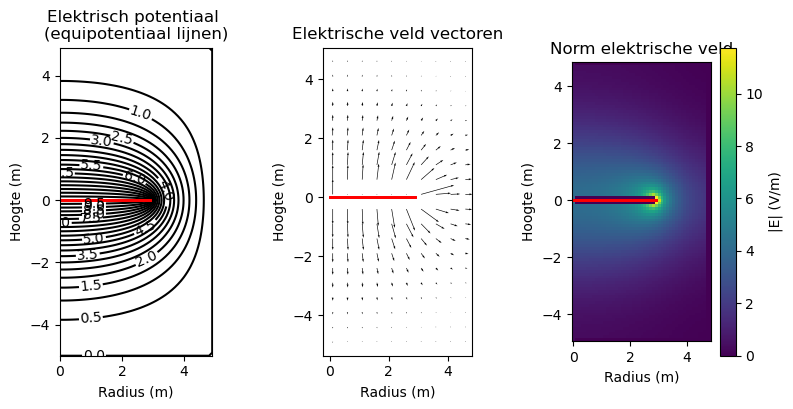

In [14]:
# Run deze cel pas deze niet aan.
V0 = 0  # electric potential at boundary of domain (V)

# Één schijf
z_pos_disk1 = 0  # z-coördinaat van de eerste geleidende schijf (m)
z_pos_disk2 = z_pos_disk1  # z-coördinaat van de tweede geleidende schijf (m)
V1 = 10  # elektrische potentiaal van de eerste geleidende schijf (V)

r, z, r_repmat, V, B, idx_R, idx_z1, idx_z2 = initialize_variables_Laplace(width_domain, disk_radius, height_domain, grid_step, z_pos_disk1, z_pos_disk2, V0, V1, V1)

"""--------------------------------------------------------------------
Veldberekening voor een geleidende schijf
"""
solve_Laplace_equation(V, B, r_repmat, grid_step, idx_z1, idx_z2, idx_R, V1, V1, 1e-3)
Er, Ez, normE = compute_E_disk(V,B,grid_step)
r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

""""---------------------------------------------------------
Plot het berekende veld
"""
plot_results_disk(Ez, Er, normE, V, r, z, grid_step, disk_radius, z_pos_disk1, z_pos_disk2)

#### Vraag 3a: De simulatie van het elektrische veld van een geleidende schijf op constant potentiaal

1. Plot de elektrische veld sterkte op de as van de schijf.
2. Print de norm van het elektrische veld op de as heel dicht bij het midden van de schijf, zorg hier voor een nette opmaak.

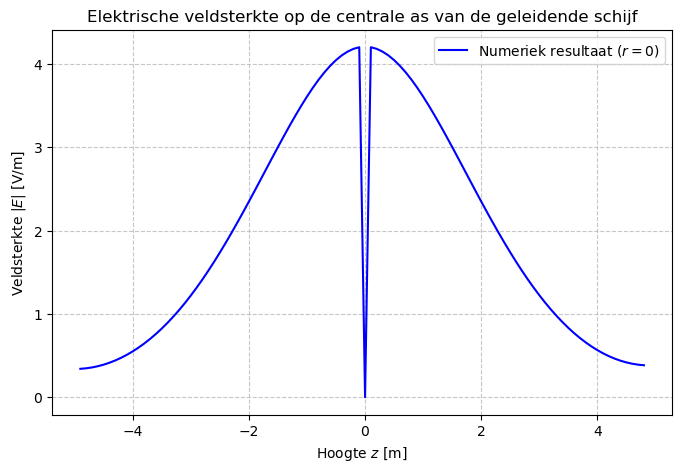

De norm van het elektrische veld in het midden (z ≈ 0) is: 0.0000 V/m


In [15]:

# We zoeken eerst de index die hoort bij de as van de schijf (r = 0)
# We gebruiken np.argmin om de waarde te vinden die het dichtst bij 0 ligt
idx_r_as = np.argmin(np.abs(r_for_E))

# We halen de z-component van het elektrische veld op voor deze specifieke as 
# Vanwege de rotatiesymmetrie is dit de totale veldsterkte op de as
Ez_as = Ez[:, idx_r_as]

z
plt.figure(figsize=(8, 5))
plt.plot(z_for_E, np.abs(Ez_as), 'b-', label='Numeriek resultaat ($r=0$)')


plt.title("Elektrische veldsterkte op de centrale as van de geleidende schijf")
plt.xlabel("Hoogte $z$ [m]")
plt.ylabel("Veldsterkte $|E|$ [V/m]")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()


idx_z_center = np.argmin(np.abs(z_for_E))
E_waarde_midden = np.abs(Ez_as[idx_z_center])




print(f"De norm van het elektrische veld in het midden (z ≈ 0) is: {E_waarde_midden:.4f} V/m")


#### Vraag 3b: De oppervlakte lading in het midden van een geleidende schijf op constant potentiaal

1. Met welke formule kan je de oppervlaktelading benaderen in het midden van de schijf($r=0$, $z=0$)?
2. Print netjes de benadering van de oppervlakte lading in het midden van de schijf.

##### Antwoord 3b


Om de oppervlaktelading $\sigma$ in het midden van de geleidende schijf ($r=0, z=0$) te bepalen, maken we gebruik van de randvoorwaarden van het elektrisch veld bij een geleider. Volgens de wet van Gauss is de sprong in de normaalcomponent van het elektrisch veld bij een geladen oppervlak direct gerelateerd aan de lokale ladingsdichtheid:

$$\Delta E_z = \frac{\sigma}{\epsilon_0}$$

Vanwege de symmetrie van de schijf is het veld net boven het oppervlak ($E_z^+$) even groot maar tegengesteld aan het veld net onder het oppervlak ($E_z^-$). De totale sprong $\Delta E_z$ is dus gelijk aan $2 \cdot E_{z,midden}$, waarbij $E_{z,midden}$ de veldsterkte is die we vlak boven de schijf hebben gemeten in vraag 3a.

De formule om de oppervlaktelading in het midden te benaderen is dan:

$$\sigma_{midden} = 2 \epsilon_0 E_{midden}$$

Hierbij is $E_{midden}$ de norm van het elektrisch veld op de as ($r=0$) op een hoogte $z$ die zo dicht mogelijk bij de schijf ligt ($z \approx 0^+$).

In [16]:

###
###Hier de code voor vraag 3b.2###
###

# 1. We halen de waarde rechtstreeks uit de simulatie-data van de geleidende schijf
# We zoeken de as (r=0)
idx_r_as = np.argmin(np.abs(r_for_E))

# We zoeken het puntje net boven de schijf (z ≈ 0.1)
# Dit is meestal de eerste index waar z > 0
idx_z_vlak_boven = np.where(z_for_E > 0)[0][0]


E_veld_midden = np.abs(Ez[idx_z_vlak_boven, idx_r_as])

# 2. Bereken de oppervlaktelading sigma met de formule: sigma = 2 * epsilon0 * E
sigma_midden = 2 * epsilon0 * E_veld_midden


print(f"Gemeten veldsterkte E op de as (z ≈ 0+): {E_veld_midden:.4f} V/m")
print(f"Berekende ladingsdichtheid sigma_midden: {sigma_midden:.4e} C/m^2")


Gemeten veldsterkte E op de as (z ≈ 0+): 4.2018 V/m
Berekende ladingsdichtheid sigma_midden: 7.4406e-11 C/m^2


#### Vraag 3c: De oppervlaktelading van een geleidende schijf op constant potentiaal

De oppervlakte lading $\sigma(r)$ van een geleidende schijf met straal $R$ is niet uniform verdeeld over de schijf, maar wordt gegeven door (Problems 2.58 and 2.63 Griffiths 5th edition):
$$\sigma(r) = \frac{Q}{2 \pi R \sqrt{R^2 - r^2}}$$

1. Bereken de totale lading op de schijf met behulp van vraag 3a en 3b.
2. Vergelijk de oppervlakte lading in het centrum van de geleidende schijf met dat van een uniform geladen schijf met dezelfde totale lading.
3. Plot de oppervlakte lading van de geleidende schijf met de berekende lading $Q$, tussen $r = 0$ en $R$.
4. Plot in hetzelfde figuur de oppervlaktelading van een uniform geladen schijf met dezelfde lading $Q$.


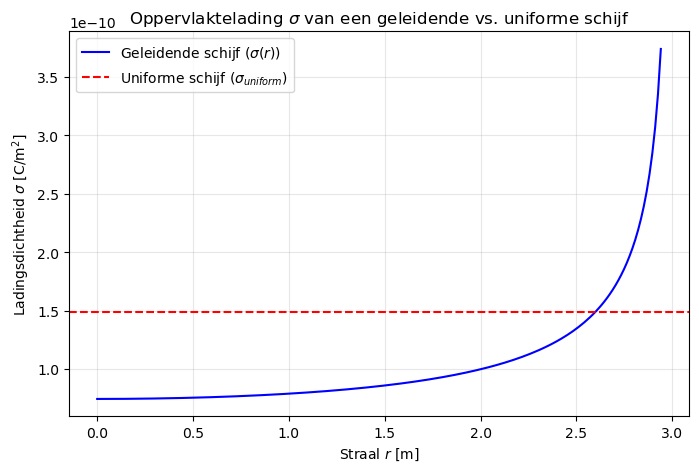

Totale lading Q:                4.2076e-09 C
Sigma midden (geleidend):       7.4406e-11 C/m^2
Sigma uniform (zelfde Q):       1.4881e-10 C/m^2
Verhouding (uniform/midden):    2.0 (verwacht: 2.0)


In [17]:

# 1. Bereken de totale lading Q op de schijf (Vraag 3c.1)
# De theorie (Griffiths) geeft: sigma(0) = Q / (2 * pi * R^2)
# Dus: Q = sigma_midden * 2 * pi * R^2
Q_totaal = sigma_midden * (2 * np.pi * disk_radius**2) #

# 2. Bepaal de uniforme ladingsdichtheid voor vergelijking (Vraag 3c.2)
# Voor een uniforme schijf is sigma = Q / (pi * R^2)
sigma_uniform = Q_totaal / (np.pi * disk_radius**2) #


# 3. We maken een array voor r van 0 tot vlak voor de rand (om deling door 0 te voorkomen)
r_theorie = np.linspace(0, 0.98 * disk_radius, 200) 
# Formule: sigma(r) = Q / (2 * pi * R * sqrt(R^2 - r^2))
sigma_r = Q_totaal / (2 * np.pi * disk_radius * np.sqrt(disk_radius**2 - r_theorie**2)) #

# 4. Plot de resultaten 
plt.figure(figsize=(8, 5))


plt.plot(r_theorie, sigma_r, 'b-', label=r'Geleidende schijf ($\sigma(r)$)') #
plt.axhline(y=sigma_uniform, color='r', linestyle='--', label=r'Uniforme schijf ($\sigma_{uniform}$)') #


plt.title(r"Oppervlaktelading $\sigma$ van een geleidende vs. uniforme schijf")
plt.xlabel(r"Straal $r$ [m]")
plt.ylabel(r"Ladingsdichtheid $\sigma$ [C/m$^2$]")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()



print(f"Totale lading Q:                {Q_totaal:.4e} C")
print(f"Sigma midden (geleidend):       {sigma_midden:.4e} C/m^2")
print(f"Sigma uniform (zelfde Q):       {sigma_uniform:.4e} C/m^2")
print(f"Verhouding (uniform/midden):    {sigma_uniform/sigma_midden:.1f} (verwacht: 2.0)")



#### Vraag 3d: Het edge effect

1. Bepaal het maximum elektrische veld door de geleidende schijf in de simulatie.
2. Bepaal waar in de ruimte dit maximum zich bevindt.
3. Hoeveel hoger is dit maximum dan het elektrische veld in het midden van de schijf?
4. Print met een nette opmaak de waardes die je hier hebt berekend.
5. Leg uit wat de oorzaak van dit lokaal hoge elektrische veld is?


In [18]:
###
### Code voor 3d ###
###

# 1. Bepaal het maximum elektrische veld in de hele simulatie
# We gebruiken de normE matrix die de totale veldsterkte bevat
max_E_waarde = np.max(normE)

# 2. Bepaal waar in de ruimte dit maximum zich bevindt
# We zoeken de indices van de maximale waarde in de 2D matrix
idx_z_max, idx_r_max = np.unravel_index(np.argmax(normE), normE.shape)

# Vertaal deze indices terug naar de fysieke coördinaten (r en z)
r_max_locatie = r_for_E[idx_r_max]
z_max_locatie = z_for_E[idx_z_max]

# 3. Bereken de verhouding tussen het maximum en het veld in het midden
# We gebruiken hier E_veld_midden (de waarde van ~4.2 V/m uit 3b)
verhouding_edge = max_E_waarde / E_veld_midden

# 4. Resultaten


print(f"Maximum elektrisch veld:         {max_E_waarde:.4f} V/m")
print(f"Locatie van maximum:             r = {r_max_locatie:.2f} m, z = {z_max_locatie:.2f} m")
print(f"Veldsterkte in het midden:       {E_veld_midden:.4f} V/m")
print(f"Factor (Edge / Midden):          {verhouding_edge:.2f} x hoger")



Maximum elektrisch veld:         11.7530 V/m
Locatie van maximum:             r = 3.00 m, z = 0.10 m
Veldsterkte in het midden:       4.2018 V/m
Factor (Edge / Midden):          2.80 x hoger


##### Antwoord 3d.5

De oorzaak van het lokaal zeer hoge elektrische veld aan de rand van de schijf is het zogenaamde **edge effect**. Bij een geleidende schijf die op een constant potentiaal wordt gehouden, kunnen de ladingen zich vrij over het oppervlak bewegen. Omdat gelijknamige ladingen elkaar afstoten, worden ze naar de uiterste randen van de geleider geduwd om de onderlinge afstand te maximaliseren en de energie van de configuratie te minimaliseren.

Dit resulteert in een niet-uniforme ladingsverdeling waarbij de ladingsdichtheid $\sigma(r)$ sterk toeneemt naarmate men dichter bij de rand ($r=R$) komt. Zoals we hebben gezien in de theoretische formule voor een geleidende schijf, gaat de ladingsdichtheid bij een oneindig scherpe rand theoretisch zelfs naar oneindig:
$$\sigma(r) = \frac{Q}{2\pi R\sqrt{R^2-r^2}}$$

Aangezien de sterkte van het elektrisch veld vlak boven het oppervlak van een geleider direct evenredig is met de lokale ladingsdichtheid ($E = \sigma / \epsilon_0$), zorgt deze extreme ophoping van lading bij de rand voor de waargenomen piek in de elektrische veldsterkte. In de praktijk (en in onze simulatie) is dit effect gelimiteerd door de resolutie van het grid, maar de sterke toename ten opzichte van het midden blijft duidelijk zichtbaar.

### 4) Twee geleidende platen op potentiaal $V_1$ and $-V_1$

In de cel hieronder wordt weer op dezelfde manier als in opdracht 3 de laplace vergelijking van deze situatie opgelost.

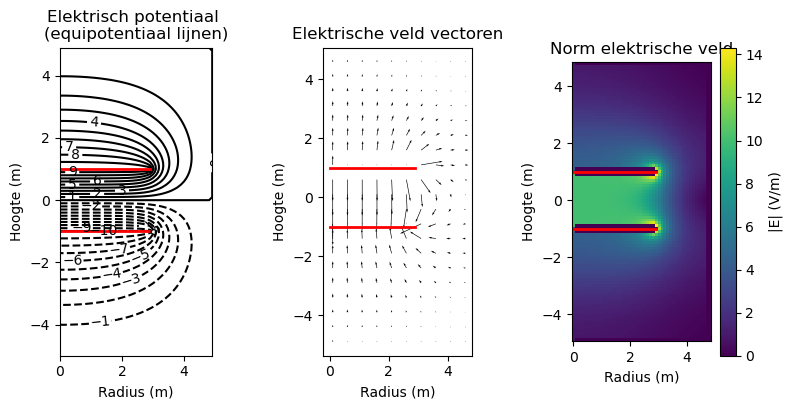

In [19]:
# Run deze cel en pas de cel aan in vraag 4f.
# Voor twee schijven
spacing_between_disks = 2  # (m)
z_pos_disk1 = spacing_between_disks/2  # z-coördinaat van de eerste geleidende schijf (m)
z_pos_disk2 = -spacing_between_disks/2  # z-coördinaat van de tweede geleidende schijf (m)
V1 = 10  # elektrische potentiaal van de eerste geleidende schijf (V)
V2 = -10  # elektrische potentiaal van de tweede geleidende schijf (V)

r, z, r_repmat, V, B, idx_R, idx_z1, idx_z2 = initialize_variables_Laplace(width_domain, disk_radius, height_domain, grid_step, z_pos_disk1, z_pos_disk2, V0, V1, V2)

"""--------------------------------------------------------------------
Veldberekening voor de twee geleidende schijven
"""
solve_Laplace_equation(V, B, r_repmat, grid_step, idx_z1, idx_z2, idx_R, V1, V2, 1e-3)
Er, Ez, normE = compute_E_disk(V, B, grid_step)
r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

""""---------------------------------------------------------
Plot het berekende veld
"""
plot_results_disk(Ez, Er, normE, V, r, z, grid_step, disk_radius, z_pos_disk1, z_pos_disk2)


#### Vraag 4a: Het $z$-component van het numeriek berekende elektrische veld van twee geleidende platen

1. Plot het $z$-component van het numeriek berekende elektrische veld op de as van de schijven.


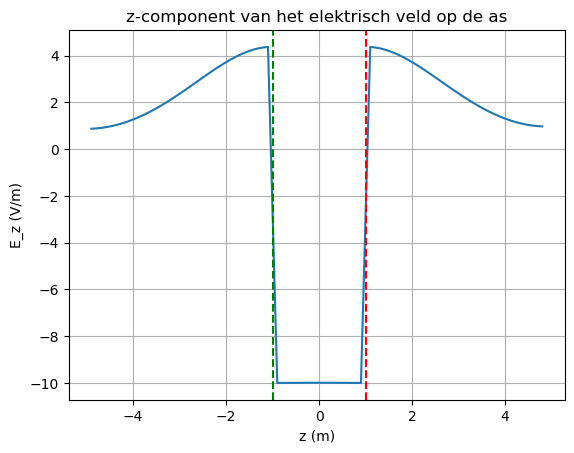

In [20]:
###
###your code here###
###

Ez_axis = Ez[:, 0]   # veld op de as r = 0

plt.figure()
plt.plot(z_for_E, Ez_axis)

plt.axvline(z_pos_disk1, color='red', linestyle='--')
plt.axvline(z_pos_disk2, color='green', linestyle='--')

plt.xlabel("z (m)")
plt.ylabel("E_z (V/m)")
plt.title("z-component van het elektrisch veld op de as")
plt.grid()

plt.show()

#### Vraag 4b: Verschillen tussen verschillende configuraties

1. Gegeven het potentiaal tussen twee geleidende platen, wat is het theoretische elektrische veld in elke regio? Laat dit zien met een afleiding en een schets die de verschillende regio's aangeeft.
2. Beschrijf het numeriek berekende elektrische veld op de as van de schijven, komt dit overeen met het theoretische elektrische veld?
3. Vergelijk het numeriek berekende elektrische veld tussen de twee schijven ($r=0$ and $z=0$) met dat van een enkele geleidende schijf op hetzelfde potentiaal(vraag 3a), welk voordeel heeft deze configuratie?

##### Antwoorden 4b

*Laat in deze markdown cel je antwoorden op vraag 4b zien.*


1.Tussen twee evenwijdige geleidende platen op +𝑉1 +V1 en −𝑉1−V1, gescheiden door afstand 𝑑, is het potentiaal lineair en het elektrische veld constant:
𝐸=2𝑉1/𝑑.
Buiten de platen is het elektrische veld in het ideale geval nul. Er zijn dus drie regio’s: buiten–tussen–buiten, waarbij alleen tussen de platen een niet-nul veld aanwezig is.
2.Langs de as (𝑟=0) is het numeriek berekende elektrische veld tussen de schijven vrijwel constant en komt goed overeen met de theoretische waarde 
𝐸=2𝑉1/𝑑
Kleine afwijkingen treden op nabij de schijven en buiten het tussenliggende gebied door rand- en discretisatie-effecten.
3.Vergeleken met één enkele geleidende schijf is het veld tussen twee schijven homogener en beter begrensd. Het voordeel van deze configuratie is dat zij een vrijwel uniform elektrisch veld oplevert tussen de platen.

#### Vraag 4c: De capaciteit tussen twee geleidende platen

1. Bepaal de verwachte oppervlakte lading op de binnenzijde van een van de schijven.
2. Bepaal de verwachte totale lading op beide schijven.
3. Bepaal de capaciteit van deze situatie.
4. Print alle bepaalde waardes op een nette en overzichtelijke manier.

In [21]:
###
###your code here###
###
import numpy as np

# Constantes
eps0 = 8.854187817e-12  # vacuum permittivity (F/m)

# Gegeven parameters
V1 = 10.0              # potentiaal van de platen (V)
d = 2.0                # afstand tussen de platen (m)
R = disk_radius        # straal van de schijven (m)

# Oppervlak  schijf
A = np.pi * R**2

# 1. Oppervlakteladingsdichtheid binnenzijde
sigma = eps0 * (2 * V1 / d)

# 2. Totale lading schijf 
Q = sigma * A

# 3. Capaciteit
C = eps0 * A / d

# 4. Overzicht
print("=== Vraag 4c: Capaciteit tussen twee geleidende platen ===")
print(f"Oppervlakteladingsdichtheid σ : {sigma:.3e} C/m^2")
print(f"Lading per schijf Q         : {Q:.3e} C")
print(f"Capaciteit C               : {C:.3e} F")

=== Vraag 4c: Capaciteit tussen twee geleidende platen ===
Oppervlakteladingsdichtheid σ : 8.854e-11 C/m^2
Lading per schijf Q         : 2.503e-09 C
Capaciteit C               : 1.252e-10 F


#### Vraag 4d: Theoretische oppervlakte lading

1. Is de oppervlaktelading aan de buitenkant van de schijven gelijk aan nul, beargumenteer waarom wel of niet.
2. Wat is het elektrische veld nabij het oppervlak van een geleider?

##### Antwoorden 4d

1.De oppervlaktelading aan de buitenkant is in het ideale geval nul. Voor eindige schijven is deze niet exact nul door rand- en franjevelden, maar wel zeer klein.
2.Net buiten een geleider is het elektrische veld loodrecht op het oppervlak en geldt
𝐸=𝜎/𝜀(0),
terwijl het veld binnen de geleider nul is.

#### Vraag 4e: Numeriek berekende ladingsdichtheid

1. Welke waarde heeft het $z$-component van het elektrische veld, op de as van de schijf net onder de onderste schijf.
2. Wat is volgens de formule uit vraag 4d 2 de ladingsdichtheid aan de onderkant van de onderste geleidende plaat.
3. Welke waarde heeft het $z$-component van het elektrische veld, op de as van de schijf net boven de onderste schijf.
4. Wat is volgens de formule uit vraag 4d 2 de ladingsdichtheid aan de bovenkant van de onderste geleidende plaat.
5. Print de bepaalde waardes op een nette en overzichtelijke manier.

In [22]:

import numpy as np

# Gebruik de epsilon0 die al eerder is gedefinieerd
# We kijken naar de onderste schijf (z = -1.0 m)

# 1. Vind de index van de onderste schijf
idx_z_onderste_schijf = np.argmin(np.abs(z_for_E - (-1.0)))

# 2. Definieer de punten net onder en net boven deze schijf
# We nemen een kleine marge (bijv. 2 gridstappen) om buiten de onzekere zone van de afgeleide te blijven
idx_onder = idx_z_onderste_schijf - 2
idx_boven = idx_z_onderste_schijf + 2

# 3. Haal de z-component van het elektrisch veld op de as (r=0)
# De index voor r=0 op de as van r_for_E
idx_r_as = np.argmin(np.abs(r_for_E))

Ez_onder = Ez[idx_onder, idx_r_as]
Ez_boven = Ez[idx_boven, idx_r_as]

# 4. Bereken de ladingsdichtheid sigma = epsilon0 * E
sigma_onderkant = epsilon0 * np.abs(Ez_onder)
sigma_bovenkant = epsilon0 * np.abs(Ez_boven)

print("=== Vraag 4e: Numerieke Ladingsdichtheid ===")
print(f"Ez net onder onderste schijf: {Ez_onder:.3f} V/m")
print(f"sigma onderkant schijf:      {sigma_onderkant:.3e} C/m^2")
print(f"Ez net boven onderste schijf: {Ez_boven:.3f} V/m")
print(f"sigma bovenkant schijf:      {sigma_bovenkant:.3e} C/m^2")

=== Vraag 4e: Numerieke Ladingsdichtheid ===
Ez net onder onderste schijf: 4.355 V/m
sigma onderkant schijf:      3.856e-11 C/m^2
Ez net boven onderste schijf: -10.003 V/m
sigma bovenkant schijf:      8.857e-11 C/m^2


#### Vraag 4f: Conclusies over de ladingsdichtheid op de twee schijven

1. Wat kan je uit vraag 4d en e concluderen over de daadwerkelijke lading op een schijf in tegenstelling tot de berekende lading in vraag 4c?
2. Wat is de invloed hiervan op de capaciteit berekend in vraag 4c?
3. Run de cel net onder het kopje vraag 4 opnieuw, maar dan met een kleinere afstand tussen de schijven, wat verandert er?

##### Antwoorden 4f

1. **Verschil in lading:** Uit vraag 4d en 4e blijkt dat de lading niet alleen aan de binnenzijde van de schijf zit. De berekening in 4c ging uit van een ideaal veld dat alleen tussen de platen bestaat. In de simulatie zien we echter dat er ook een aanzienlijk veld (en dus lading) aan de buitenkant van de schijven aanwezig is door franjevelden (edge effects).

2. **Invloed op de capaciteit:** Doordat er ook lading aan de buitenkant en op de randen van de schijven wordt opgeslagen, is de totale lading $Q$ bij een gelijkblijvend potentiaalverschil groter dan de ideale waarde uit 4c. Omdat $C = Q/V$, is de praktische (werkelijke) capaciteit hierdoor juist iets **groter** dan de ideale berekende waarde.

3. **Invloed van de afstand:** Wanneer de afstand tussen de schijven kleiner wordt, neemt de veldsterkte $E_z$ tussen de platen toe, wat leidt tot een hogere ladingsdichtheid $\sigma$ aan de binnenzijde. Hierdoor stijgt de capaciteit aanzienlijk. Bovendien wordt het veld bij een kleinere afstand "idealer", omdat de relatieve invloed van de franjevelden afneemt.

### 5) Voorbereidende opdracht voor de fysieke DEF ontwerpopdracht

In deze vraag zullen we ingaan op benodigde voorkennis voor de fysieke ontwerpopdracht "Maak een sensor met condensatoren". De formules die je in deze opdracht opstelt, heb je nodig gedurende de fysieke ontwerpopdracht.

In deze vraag zullen we kijken naar de ideale vlakke plaat condensator. Als de afstand tussen de platen veel kleiner is dan de grootte van de platen dan wordt de aanname gemaakt dat het veld tussen de platen constant is. Deze aanname zal niet helemaal overeenkomen met de werkelijkheid, zoals je in deze opdracht en de fysieke DEF ontwerpopdracht achter zal komen.

#### Vraag 5a: Functies voor de capaciteit van enkele opdrachten

1. Vind de formule voor de capaciteit van een vlakke plaat condensator en een cilinder condensator, onder de aanname dat de afstand tussen de platen veel kleiner is dan het oppervlakte van de condensator (vlakke plaat aanname).
2. Schrijf een python functie die de relevante parameters als input neemt en de capaciteit van een vlakke plaat condensator als output heeft.
3. Vind de formule voor de capaciteit van een cilinder condensator onder de aanname dat de afstand tussen de binnen en buiten wand klein is.
4. Schrijf een python functie die de relevante parameters als input neemt en de capaciteit van een cilinder condensator als output heeft.

In [23]:
def vlakkeplaat(epsilon_r, oppervlakte, afstand):
    # epsilon0 is al gedefinieerd in de template
    C = (epsilon0 * epsilon_r * oppervlakte) / afstand
    return C

def cilinder(epsilon_r, lengte, r_binnen, r_buiten):
    C = (2 * np.pi * epsilon0 * epsilon_r * lengte) / np.log(r_buiten / r_binnen)
    return C




In [24]:
import numpy as np
import matplotlib.pyplot as plt

epsilon0 = 8.85 * 10**-12 # Vacuum constante perm.
epsilon_r = 2.3 # Voor papier bijv.
w = 0.03 # m
x_cm = np.linspace(0,10,100)
x_m = x_cm/100
A = w * x_m # m
A_max = w * 0.1 # m
d = 0.0001 # m
C_parasitair = 10e-12 # Schatting voor draden/breadboard
C = vlakkeplaat(epsilon_r,A,d) + C_parasitair # in F
C_min = vlakkeplaat(epsilon_r,0,d) + C_parasitair # in F
C_max = vlakkeplaat(epsilon_r,A_max,d) + C_parasitair # in F

print(f"De waarde van de maximale capaciteit voor deze schuifsensor is {C_max*1e12:.2f} pF")
print(f"De waarde van de minimale capaciteit voor deze schuifsensor is {C_min*1e12:.2f} pF")


De waarde van de maximale capaciteit voor deze schuifsensor is 620.65 pF
De waarde van de minimale capaciteit voor deze schuifsensor is 10.00 pF


#### Vraag 5b: Capaciteit van enkele simpele condensatoren

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.
Hieronder staan een aantal condensatoren waarvoor jullie de capaciteit gaan berekenen. Print de capaciteit van elke condensator op een nette en overzichtelijke manier.
1. Bereken de capaciteit van een condensator gemaakt van twee vierkante plaatjes van 10 bij 10 cm met een plaatafstand van 1 mm en lucht als medium?
2. Bereken de capaciteit van een cilinder condensator met een binnendiameter van 9 mm en een buitendiameter van 10 mm met een lengte van 10 cm en lucht als medium?
3. Bereken de capaciteit van de condensatoren als de afstand tussen de platen verdubbeld
4. Bereken de capaciteit van de condensatoren uit 1 en 2 hierboven beschreven als ze gevuld zijn met water.
5. Bereken de capaciteit van de condensatoren uit 1 en 2 hierboven als de holte gevuld is met PVC.


In [25]:
# Constanten
eps_lucht = 1.0006
eps_water = 80
eps_pvc = 3

# 1. Vierkante plaat (10x10 cm, 1 mm afstand, lucht)
opp_5b1 = 0.1 * 0.1 # 100 cm^2 naar m^2
C1 = vlakkeplaat(eps_lucht, opp_5b1, 0.001)

# 2. Cilinder (ID 9mm, OD 10mm, L 10cm, lucht)
C2 = cilinder(eps_lucht, 0.1, 0.0045, 0.005) 

# 3. Afstand verdubbeld (voor plaat 1)
C1_dubbel = vlakkeplaat(eps_lucht, opp_5b1, 0.002)

# 4. Gevuld met water
C1_water = vlakkeplaat(eps_water, opp_5b1, 0.001)


print(f"C1 (Plaat, lucht): {C1:.2e} F")
print(f"C2 (Cilinder, lucht): {C2:.2e} F")
print(f"C1 (Afstand x2): {C1_dubbel:.2e} F")
print(f"C1 (Water): {C1_water:.2e} F")

C1 (Plaat, lucht): 8.86e-11 F
C2 (Cilinder, lucht): 5.28e-11 F
C1 (Afstand x2): 4.43e-11 F
C1 (Water): 7.08e-09 F


#### Vraag 5c: Condensatoren uit het dagelijkse leven

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.
Hieronder is een foto te zien van condensatoren die in het dagelijkse leven gebruikt wordt.
Print de capaciteiten in deze vraag op een nette en overzichtelijke manier.
1. In figuur 5.1 is een condensator te zien van 1 $\micro$F, stel deze condensator kan geapproximeerd worden als een cilinder condensator met binnendiameter 5 mm en een buitendiameter van 6 mm. Bereken wat de lengte van de condensator dan zou zijn.
Stel dat we een vierkante plaat condensator hebben van 1 $\micro$F.
2. Bereken hoe lang de vlakke plaat condensator moet zijn als er 0.5 mm tussen de platen zit en de platen 6 mm breed zijn.

![figure 5.1](figures/Condensator_1_uF.jpg)

##### Figure: 5.1 Een 1 microfarad condensator.

In [26]:
###
### code voor 5c ###
###

# Constanten voor deze vraag
C_target = 1e-6  # De gewenste capaciteit van 1 microFarad (F)
eps_r_lucht = 1.0006 # Dielektrische constante van lucht

# --- 5c.1: Cilinder condensator ---
# Gegeven: ID = 5mm, OD = 6mm
r_in = 0.0025 # Straal (m)
r_uit = 0.0030 # Straal (m)

# Formule: C = (2 * pi * eps0 * epsr * L) / ln(r_uit / r_in)
# Omschrijven naar L: L = (C * ln(r_uit / r_in)) / (2 * pi * eps0 * epsr)
L_cilinder = (C_target * np.log(r_uit / r_in)) / (2 * np.pi * epsilon0 * eps_r_lucht)

# --- 5c.2: Vlakke plaat condensator ---
# Gegeven: afstand d = 0.5mm, breedte w = 6mm
d_plaat = 0.0005 # (m)
breedte_plaat = 0.006 # (m)

# Formule: C = (eps0 * epsr * A) / d  waarbij A = breedte * lengte
# Omschrijven naar L: L = (C * d) / (eps0 * epsr * breedte)
L_vlakke_plaat = (C_target * d_plaat) / (epsilon0 * eps_r_lucht * breedte_plaat)


print(f"1. Benodigde lengte cilinder (ID=5mm, OD=6mm): {L_cilinder:.2f} meter")
print(f"2. Benodigde lengte vlakke plaat (d=0.5mm, w=6mm): {L_vlakke_plaat:.2f} meter")


1. Benodigde lengte cilinder (ID=5mm, OD=6mm): 3276.83 meter
2. Benodigde lengte vlakke plaat (d=0.5mm, w=6mm): 9410.55 meter


#### Vraag 5d: Hoge capaciteit condensatoren

1. Beargumenteer of je antwoorden uit vraag 5c realistisch zijn.
2. Bekijk je formule uit vraag 5a en bedenk hoe ze dit binnen in de condensator opgelost hebben.

##### Antwoorden 5d

Op basis van de berekeningen in vraag 5c kunnen we concluderen dat het **niet realistisch** is om een condensator van 1 $\mu$F te bouwen met lucht als diëlektricum en een plaatafstand van 0,5 mm. Een lengte van circa 3 tot 9 kilometer past uiteraard niet in een gangbaar elektronisch apparaat of op een printplaat.

De condensatoren die we in de praktijk gebruiken (zoals die in de afbeeldingen van het dictaat), zijn echter klein genoeg om tussen je vingers te houden. Dit wordt mogelijk gemaakt door drie belangrijke ontwerpkeuzes:

1. Het vergroten van de relatieve permittiviteit ($\epsilon_r$): In plaats van lucht worden materialen gebruikt met een veel hogere $\epsilon_r$, zoals keramiek, mica of elektrolyten. Hierdoor neemt de capaciteit met een factor 10 tot wel 10.000 toe zonder de afmetingen te veranderen.
2. Het minimaliseren van de afstand ($d$): Door gebruik te maken van flinterdunne isolatielagen (in de orde van micrometers in plaats van de 0,5 mm uit de som), wordt de capaciteit volgens $C \propto 1/d$ enorm vergroot.
3. Het oprollen van het oppervlak: Om een groot oppervlak $A$ in een klein volume te passen, worden de geleidende folies en het diëlektricum samen opgerold tot een compacte cilinder. Dit verklaart de typische cilindrische vorm van elektrolytische condensatoren.

#### Vraag 5e: Condensator in een achtbaan

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.

Met het vak inleidend practicum zijn jullie naar Drievliet gegaan om daar metingen aan de attracties te doen. In Drievliet staat de achtbaan Formule X, deze achtbaan heeft een topsnelheid van 70 $\frac{\text{km}}{\text{h}}$ en bevat een treintje met plek voor 6 mensen. Deze snelheid bereikt de achtbaan door heel snel een karretje weg te schieten, dit wordt gedaan door de treintjes met een lineaire inductie motor te versnellen. Om de impact hiervan op het stroomnet te beperken gebruiken zij een condensator om de energie op te slaan en dan in een keer af te staan aan het treintje. In deze opdracht gaan we kijken wat de afmetingen zouden moeten zijn als ze vlakke plaat condensatoren zouden gebruiken.

De energie die opgeslagen is in een condensator kan berekend worden met de onderstaande formule.

$E = \frac{1}{2} CV^2$
Hierin is $E$ de totaal opgeslagen energie $C$ de capaciteit en $V$ het voltage waarop de condensator opereert, in dit geval $10$ $kV$.
1. Schat de massa van een treintje dat afgeschoten wordt.
2. Bereken de totale energie van het treintje na het afschieten.
3. Bereken de totale capaciteit van de condensator.
4. Bereken het oppervlakte van een vlakke plaat condensator die deze capaciteit heeft als die gevuld is met water en de platen 1 mm van elkaar afstaan.
5. Print alle berekende waardes op een nette en overzichtelijke manier.
6. Is dit realistisch, bedenk een manier hoe dit toch kan in een relatief klein volume.


**Massa schatting:**
Om de benodigde energie te berekenen, maken we de volgende aannames: Massa ($m$): Een treintje voor 6 personen weegt leeg ongeveer $2000 \text{ kg}$. Met 6 volwassenen van gemiddeld $75 \text{ kg}$ erbij ($450 \text{ kg}$), komen we op een totale massa van $m \approx 2500 \text{ kg}$. Snelheid ($v$): De gevraagde snelheid is $70 \text{ km/h}$. In SI-eenheden is dit $70 / 3,6 \approx 19,44 \text{ m/s}$. De kinetische energie ($E_k$) die de condensator moet leveren is:$$E_k = \frac{1}{2} m v^2$$

In [27]:
###
### code hier voor 5e ###
###

# 1. Berekening van de kinetische energie
massa_trein = 2500 # kg
snelheid_ms = 70 / 3.6 # m/s
E_kinetisch = 0.5 * massa_trein * snelheid_ms**2

# 2. Benodigde capaciteit C bij een spanning van 10 kV
# Formule: E = 0.5 * C * V^2  =>  C = 2E / V^2
spanning = 10000 # Volt
C_nodig = (2 * E_kinetisch) / (spanning**2)

# 3. Benodigd oppervlak A met water als diëlektricum
# We nemen aan: d = 1 mm (0.001 m) en eps_r_water = 80
d_isolatie = 0.001 
eps_r_water = 80
# Formule: C = (eps0 * epsr * A) / d  =>  A = (C * d) / (eps0 * epsr)
A_oppervlak = (C_nodig * d_isolatie) / (epsilon0 * eps_r_water)


print(f"Benodigde energie:          {E_kinetisch:.2e} J")
print(f"Benodigde capaciteit C:     {C_nodig:.4f} F (of {C_nodig*1000:.1f} mF)")
print(f"Benodigd oppervlak A:       {A_oppervlak:.1f} m^2")


Benodigde energie:          4.73e+05 J
Benodigde capaciteit C:     0.0095 F (of 9.5 mF)
Benodigd oppervlak A:       13350.5 m^2


##### Antwoorden 5e
De berekening laat zien dat de benodigde energie ($4{,}73 \times 10^5\text{ J}$) technisch haalbaar is, maar dat de uitvoering met een standaard parallelle-plaatcondensator onmogelijk is vanwege het enorme benodigde oppervlak van ruim $13.000\text{ m}^2$. In de praktijk worden daarom technieken zoals supercondensatoren of extreem dunne isolatielagen gebruikt om dit oppervlak met een factor duizend of meer te verkleinen."

#### Vraag 5f: Veranderende capaciteit

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.

1. Bereken en plot de capaciteit van een vlakke plaat condensator van $10$ bij $10$ $cm$ waarbij de afstand tussen de platen lineair toeneemt van $0.5$ $mm$ tot $5$ $mm$.
2. Bereken en plot de capaciteit van een cilinder condensator met een binnendiameter van 9 mm en een buitendiameter van 10 mm en 10 cm lang, waarbij de binnencilinder er langzaam in 10 seconde uitgetrokken wordt.

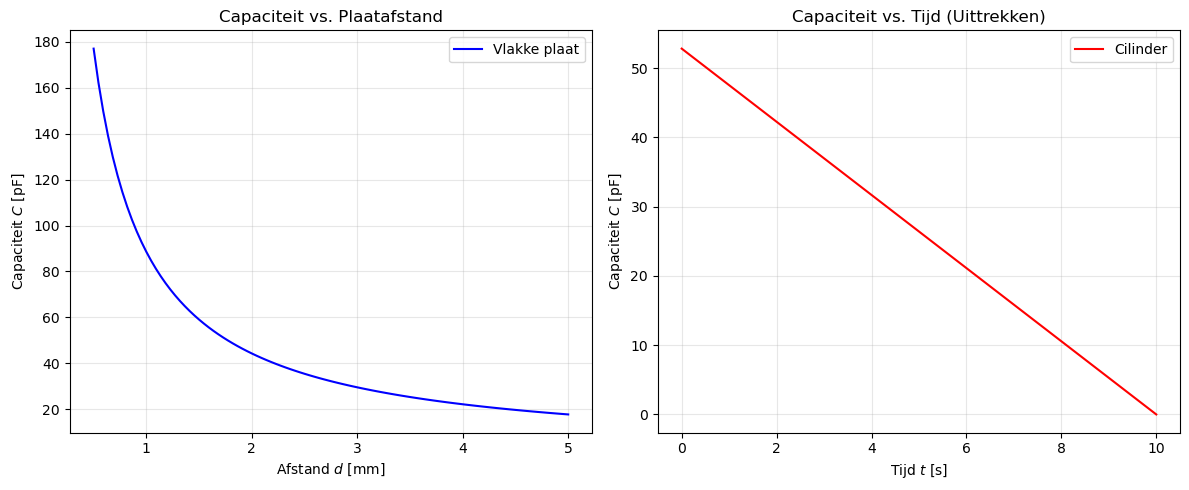

In [28]:

# Variabele afstand voor de vlakke plaat (d van 0.5 mm tot 5 mm)
d_as = np.linspace(0.0005, 0.005, 100) # Afstand in meters
C_plaat_var = vlakkeplaat(eps_lucht, 0.1*0.1, d_as)

# Variabele lengte voor de cilinder (uittrekken over 10 seconden)
# We nemen aan dat de cilinder in 10 seconden van 10 cm naar 0 cm gaat
t_as = np.linspace(0, 10, 100)
L_as = np.linspace(0.1, 0.0, 100) # Lengte in meters
C_cil_var = cilinder(eps_lucht, L_as, 0.0045, 0.005)
plt.figure(figsize=(12, 5))

# Subplot 1: Vlakke plaat (1/d verband)
plt.subplot(1, 2, 1)
plt.plot(d_as * 1000, C_plaat_var * 1e12, 'b-', label='Vlakke plaat')
plt.title("Capaciteit vs. Plaatafstand")
plt.xlabel("Afstand $d$ [mm]")
plt.ylabel("Capaciteit $C$ [pF]")
plt.grid(True, alpha=0.3)
plt.legend()

# Subplot 2: Cilinder (lineair verband)
plt.subplot(1, 2, 2)
plt.plot(t_as, C_cil_var * 1e12, 'r-', label='Cilinder')
plt.title("Capaciteit vs. Tijd (Uittrekken)")
plt.xlabel("Tijd $t$ [s]")
plt.ylabel("Capaciteit $C$ [pF]")
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

## Stop hier met werken tot na de fysieke ontwerpopdracht in week 3.

### 6) Reflectie opdracht voor na de fysieke ontwerpopdracht


Als het goed is, heeft ieder teamlid van deze simulatie-opdracht een andere opstelling ontworpen hebben tijdens de fysieke ontwerpopdracht. Kies in goed overleg voor deze opdracht een van jullie twee ontwerpen.

Voeg hieronder eerst een foto in van je opstelling die je gekozen hebt.

Jullie gaan in deze opdracht het verschil tussen jullie voorspelde verband en jullie uiteindelijke verkregen kalibratie grafiek proberen te verklaren. Er zijn hiervoor drie mogelijke paden die jullie kunnen kiezen om te onderzoeken, Kies deel a, b of c en werk die volledig uit voor jullie ontwerp. Let op je hoeft er maar een uit te werken.

Verander de tekst hieronder zodat deze naar jouw foto verwijst. Zorg dat de foto in de map figures staat!
![figure 5.1](figures/Marjoksi.jpeg)


#### Vraag 6a: Dunne laag niet meegerekende diëlektricum
Deze vraag is goed om te kiezen als je in je ontwerp een kleine laag extra materiaal hebt en deze tijdens de ontwerpopdracht niet hebben meegenomen in je theoretisch kalibratie grafiek.

1. Maak een nieuwe schets van je opstelling waarbij je de dikte van het extra diëlektricum meeneemt.
2. Leid de analytische oplossing af van de capaciteit van de hierboven getekende situatie.
3. Programmeer de analytische oplossing in python.
4. Maak hierna een plot van het kalibratiegrafiek, oude en nieuwe analytische oplossing in een grafiek.
5. Beschrijf en verklaar de verschillen tussen de grafieken.


##### Antwoorden 6a

*Laat in deze cel je analytische oplossing met schets zien, dit mag met foto's of via LATEX.*

In [29]:
# Schrijf hier de code voor je oplossing. Gebruik hier je eerder gemaakte functies
# def condensator_extra_laag(#jouw variabelen): # Schrijf hier jouw functie
    ## je functie


### Maak hier je plot

##### Antwoorden 6a

*Beschrijf en verklaar je verschillen in deze markdown cel.*

#### Vraag 6b1: Lading op een condensator met het edge effect meegenomen

In deze opdracht gaan we verder in op het Edge effect en de invloed daarvan op de praktische capaciteit. Deze opdracht bouwt voort op de vraag 4.3.
Jullie hebben tijdens de ontwerpopdracht vierkante platen gebruikt in tegenstelling tot de ronde platen waarvoor de factoren in figure[label] zijn afgeleid. Er is onderzoek gedaan naar de factoren waarmee de praktische capaciteit vergeleken met de daadwerkelijke capaciteit verschilt dat onderzoek vind je hier: https://ieeexplore.ieee.org/stamp/stamp.jsp?tp=&arnumber=311759. Zoek in het onderzoek tabel 1 en formules 22 en 36 op.

1. Vergelijk de factor waarmee de schijf(disk) condensator verschilt met die van de vierkante plaat, kunnen we de vierkante plaat factor benaderen met de factor voor een disk condensator? Vergelijk het procentuele verschil tussen de factoren van de circulaire en vierkante platen, met de onzekerheden die in de meting zitten.



##### Antwoord 6b1

*Vergelijk hier de factoren tussen de circulaire en vierkante vlakke plaat condensatoren.*

#### Vraag 6b2: Capaciteit van een condensator met het edge effect meegenomen

Vanaf hier nemen we aan dat factor van de circulaire platen ongeveer gelijk is aan de factor voor vierkante platen. De factor die de capaciteit van de vlakke plaat approximatie linkt aan de werkelijke capaciteit noemen we vanaf nu de idealiteitsfactor.

1. Bereken de daadwerkelijke theoretische capaciteit van de condensator uit de sanity check 3 van de fysieke ontwerpopdracht en print deze op een nette manier.
2. Vergelijk dit met de daadwerkelijke theoretische capaciteit met de capaciteit die je op de dag zelf hebt gemeten.

Vanaf hier gaan we verder met jullie sensor van de ontwerpopdracht "Maak een sensor met condensatoren":

3. Reken je theoretische kalibratie grafiek om met de idealiteitsfactor.
4. Vergelijk je nieuwe theoretische kalibratiegrafiek van je praktische kalibratiegrafiek van de dag zelf.

In [30]:
# Schrijf hier jouw code die de vlakke plaat capaciteit omschrijft naar de werkelijke capaciteit

# def C_niet_ideaal(#relevante parameters):
    # Jouw berekeningen


##### Antwoorden 6b2

*Doe in deze markdown cel je vergelijkingen voor de sanity check condensator en je kalibratiegrafiek.*

#### Vraag 6c: Niet linear diëlektricum optie 1

Niet alle materialen zijn een lineair diëlektricum. Een aantal van de materialen die sterk niet lineair gedrag vertonen zijn: sponzen, foam & rubber. Als je in je opdracht een materiaal gebruikt heb waarvan je verwacht dat het verband sterk niet lineair is kan dit een hele goede opdracht zijn.
| Materiaal |$\chi_2$   |
| :-------------|:-------------|
| Spons|1e-17  |

Als jouw materiaal hier niet tussen staat dan kan je zelf op zoek naar een waarde van $\chi_2$ in de literatuur.

#### Vraag 6c1

1. Leidt het D veld van de condensator af uit de wet van Gauss.
2. Vindt een analytische uitdrukking voor het elektrisch veld in termen van het D veld.

##### Antwoorden 6c 1

#### 1. Afleiding van het D-veld uit de wet van Gauss
Voor een vlakke plaat condensator gebruiken we de wet van Gauss voor diëlektrica:

$$\oint \mathbf{D} \cdot d\mathbf{A} = Q_{vrij, ingesloten}$$

Omdat het veld bij een ideale vlakke plaat condensator loodrecht op de platen staat en daarbuiten nagenoeg nul is, versimpelt de integraal voor een oppervlak $A$ tot:
* **$D \cdot A = Q$**
* Hieruit volgt: **$D = \frac{Q}{A} = \sigma$**

Het $D$-veld is dus gelijk aan de vrije oppervlakteladingsdichtheid $\sigma$ en is onafhankelijk van het type diëlektricum tussen de platen.

#### 2. Analytische uitdrukking voor het elektrisch veld $E$
In een niet-lineair diëlektricum wordt het verband tussen $D$ en $E$ beschreven door:
$$D = \epsilon_0(1 + \chi_1)E + \epsilon_0 \chi_2 E^2$$

Met $\epsilon = \epsilon_0(1 + \chi_1)$ krijgen we de kwadratische vergelijking:
$$\epsilon_0 \chi_2 E^2 + \epsilon E - D = 0$$

Toepassing van de abc-formule geeft de analytische oplossing voor $E$:
$$E = \frac{-\epsilon + \sqrt{\epsilon^2 + 4 \epsilon_0 \chi_2 D}}{2 \epsilon_0 \chi_2}$$

Dit is de formule die wordt gebruikt in de Python-functie `E_condensator` om de niet-lineaire effecten te simuleren.

#### Vraag 6c2

1. Programmeer je oplossingen voor het D en E veld in python, gebruik het D veld uit je fysieke ontwerpopdracht.

Als je het elektrische veld van een vierkante vlakke plaat condensator weet kan je de capaciteit berekenen met de onderstaande formule:
$C = \frac{A
E_z \epsilon_0}{\Delta V}$

2. Plot de capaciteit van het niet lineaire diëlektricum, het theoretische kalibratiegrafiek en de uiteindelijke kalibratiegrafiek van de fysieke ontwerpopdracht.
3. Verklaar verschillen tussen de grafieken.

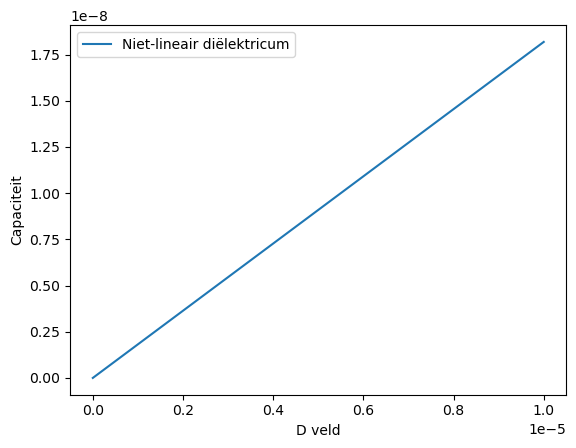

In [31]:
 # Pas deze code aan zodat jouw opstelling doorgerekend wordt

import numpy as np
import matplotlib.pyplot as plt

epsilon0 = 8.854e-12

def E_condensator(x1, x2, D):
    epsilon = epsilon0 * (1 + x1)
    return (-epsilon + np.sqrt(epsilon**2 + 4*epsilon0*x2*D)) / (2*epsilon0*x2)

D = np.linspace(0,1e-5,100)

x1 = 0.1
x2 = 1e-17

E = E_condensator(x1,x2,D)

A = 0.01
dV = 5

C = (A * E * epsilon0) / dV

plt.plot(D,C,label="Niet-lineair diëlektricum")
plt.xlabel("D veld")
plt.ylabel("Capaciteit")
plt.legend()
plt.show()

#### Vraag 7

Hoeveel van de afwijking tussen je metingen en je oorspronkelijke voorspelde kalibratiegrafiek wordt verklaard door wat je bij vraag 6 hebt uitgerekend? Kan je een (aantal) elektrisch veld en capaciteit gerelateerde reden(en) verzinnen wat de rest van de afwijking tussen meting en voorspelde kalibratiegrafiek kan verklaren.

##### Antwoorden 7

 Deel dat verklaard wordt door vraag 6
In vraag 6 is rekening gehouden met een niet-lineair diëlektricum. Daardoor verandert de relatie tussen het elektrische veld (E) en het (D)-veld. Hierdoor wordt de capaciteit niet meer perfect lineair met de spanning. Een deel van de afwijking tussen de metingen en de oorspronkelijke kalibratiegrafiek wordt dus verklaard doordat de permittiviteit van het materiaal verandert bij hogere elektrische velden.